<a href="https://colab.research.google.com/github/IndiraTejaswini/Pytorch_Neural_networks/blob/main/Copy_of_pytorch_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Tue May 19 07:47:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print(torch.__version__)

2.10.0+cu128


A torch.Tensor is a multi-dimensional matrix containing elements of a single data type. Please see torch.dtype for more details about dtype support.

A tensor can be constructed from a Python list or sequence using the torch.tensor() constructor

torch.tensor() always copies data. If you have a Tensor data and just want to change its requires_grad flag, use requires_grad_() or detach() to avoid a copy. If you have a numpy array and want to avoid a copy, use torch.as_tensor().



In [ ]:
import torch
torch.tensor([[1., -1.], [1., -1.]])

tensor([[ 1., -1.],
        [ 1., -1.]])

In [ ]:
import numpy as np
torch.tensor(np.array([[1, 2, 3], [4, 5, 6]]))

tensor([[1, 2, 3],
        [4, 5, 6]])

In [ ]:
torch.zeros([2, 4], dtype=torch.int32)
cuda0 = torch.device('cuda:0')
torch.ones([2, 4], dtype=torch.float64, device=cuda0)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]], device='cuda:0', dtype=torch.float64)

The contents of a tensor can be accessed and modified using Python’s indexing and slicing notation

In [ ]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(x[1][2])
x[0][1] = 8
print(x)


tensor(6)
tensor([[1, 8, 3],
        [4, 5, 6]])


In [ ]:
x = torch.tensor([[1]])
x.item()

1

In [ ]:
# 1. Create a tensor and track its operations for gradient calculation
x = torch.tensor([[1., -1.], [1., 1.]], requires_grad=True)

# 2. Forward Pass: Square each element, then sum them all up
out = x.pow(2).sum()

# 3. Backward Pass: Calculate the derivative (gradient) of 'out' with respect to 'x'
out.backward()

# 4. Check the results: View the calculated gradients
x.grad

tensor([[ 2., -2.],
        [ 2.,  2.]])

In [ ]:
import torch

# Create a float tensor (uses 32-bit floating points by default)
float_tensor = torch.tensor([1.5, 2.7, 3.9])
print("Original:", float_tensor.dtype)  # Output: torch.float32

# Cast to a 64-bit integer (This COPIES the data and rounds down)
int_tensor = float_tensor.to(torch.int64)
print("Changed:", int_tensor.dtype)     # Output: torch.int64
print("Values:", int_tensor)            # Output: tensor([1, 2, 3])

Original: torch.float32
Changed: torch.int64
Values: tensor([1, 2, 3])


In [ ]:
import torch

# Ensure a GPU is available
if torch.cuda.is_available():
    # Create a tensor on the CPU
    cpu_tensor = torch.tensor([10, 20, 30])
    print("Original Device:", cpu_tensor.device)  # Output: cpu

    # Move it to the GPU (COPIES memory from RAM to VRAM)
    gpu_tensor = cpu_tensor.to("cuda")
    print("New Device:", gpu_tensor.device)       # Output: cuda:0

Original Device: cpu
New Device: cuda:0


to create a tensor of random numbers we use torch.rand()


In [ ]:
# Create a random tensor of size (3, 4)
import torch
random_tensor = torch.rand(size=(3, 4))
random_tensor, random_tensor.dtype

(tensor([[0.0022, 0.4346, 0.9505, 0.8157],
         [0.7493, 0.1430, 0.8795, 0.7240],
         [0.8254, 0.8901, 0.4564, 0.2964]]),
 torch.float32)

In [ ]:
# Create a random tensor of size (224, 224, 3)
random_image_size_tensor = torch.rand(size=(224, 224, 3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

In [ ]:
# Create a tensor of all zeros
zeros = torch.zeros(size=(3, 4))
zeros, zeros.dtype

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 torch.float32)

In [ ]:
# Create a tensor of all ones
ones = torch.ones(size=(3, 4))
ones, ones.dtype

(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 torch.float32)

In PyTorch and Python, the step parameter signifies the stride or increment between consecutive numbers in a sequence.

When you use a function like torch.arange(start, end, step), it tells the computer how to count from your starting point to your ending point.

The step parameter directly changes the density and the size (shape) of your resulting tensor.

If step = 1 (Default): You get every single whole number.

If step = 2: You skip every second number (generating only evens or odds, depending on where you start).

In [ ]:
import torch
zero_to_ten_deprecated = torch.range(0, 10) # Note: this may return an error in the future


/tmp/ipykernel_2399/3826950935.py:2: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  zero_to_ten_deprecated = torch.range(0, 10) # Note: this may return an error in the future


In [ ]:
zero_to_ten = torch.arange(start=0, end=10, step=2)
zero_to_ten

tensor([0, 2, 4, 6, 8])

In [ ]:
import torch
# Can also create a tensor of zeros similar to another tensor
ten_zeros = torch.zeros_like(input=zero_to_ten) # will have same shape
ten_zeros

tensor([0, 0, 0, 0, 0])

requires_grad=True Neighbors: PyTorch starts tracking every mathematical operation performed on this tensor. It builds a dynamic computational graph behind the scenes, allowing you to call .backward() later to compute the derivatives.

In [ ]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type
                               requires_grad=False) # if True, operations performed on the tensor are recorded

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

In [ ]:
float_16_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float16) # torch.half would also work

float_16_tensor.dtype

torch.float16

In [ ]:
#Let's create a random tensor and find out details about it.

# Create a tensor
some_tensor = torch.rand(3, 4)

# Find out details about it
print(some_tensor)
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Device tensor is stored on: {some_tensor.device}") # will default to CPU

tensor([[0.9107, 0.7090, 0.8970, 0.5843],
        [0.7891, 0.2188, 0.9111, 0.4049],
        [0.9414, 0.2312, 0.7440, 0.7238]])
Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


Bassic tensor operations(Tensor Manipulation)

In [ ]:
# Create a tensor of values and add a number to it
tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [ ]:
# Multiply it by 10
tensor * 10

tensor([10, 20, 30])

Notice how the tensor values above didn't end up being tensor([110, 120, 130]), this is because the values inside the tensor don't change unless they're reassigned.

In [ ]:
# Tensors don't change unless reassigned
tensor

tensor([1, 2, 3])


Let's subtract a number and this time we'll reassign the tensor variable.

In [ ]:
# Subtract and reassign
tensor = tensor - 10
tensor

tensor([-9, -8, -7])

In [ ]:
# Add and reassign
tensor = tensor + 10
tensor

tensor([1, 2, 3])


PyTorch also has a bunch of built-in functions like torch.mul() (short for multiplication) and torch.add() to perform basic operations.

In [ ]:
# Can also use torch functions
torch.multiply(tensor, 10)

tensor([10, 20, 30])

In [ ]:
# Original tensor is still unchanged
tensor

tensor([1, 2, 3])

In [ ]:
# Element-wise multiplication (each element multiplies its equivalent, index 0->0, 1->1, 2->2)
print(tensor, "*", tensor)
print("Equals:", tensor * tensor)

tensor([1, 2, 3]) * tensor([1, 2, 3])
Equals: tensor([1, 4, 9])


PyTorch implements matrix multiplication functionality in the torch.matmul() method.

The inner dimensions must match
(3, 2) @ (3, 2) won't work

The resulting matrix has the shape of the outer dimensions:
(2, 3) @ (3, 2) -> (2, 2)


Let's create a tensor and perform element-wise multiplication and matrix multiplication on it.



In [ ]:
import torch
tensor = torch.tensor([1, 2, 3])
tensor.shape

torch.Size([3])

In [ ]:
# Element-wise matrix multiplication
tensor * tensor

tensor([1, 4, 9])

In [ ]:
# Matrix multiplication
torch.matmul(tensor, tensor)

tensor(14)

In [ ]:
# Can also use the "@" symbol for matrix multiplication, though not recommended
tensor @ tensor

tensor(14)

In [ ]:
%%time
# Matrix multiplication by hand
# (avoid doing operations with for loops at all cost, they are computationally expensive)
value = 0
for i in range(len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: user 1.37 ms, sys: 56 µs, total: 1.42 ms
Wall time: 2.44 ms


tensor(14)

You can perform transposes in PyTorch using either:

torch.transpose(input, dim0, dim1) - where input is the desired tensor to transpose and dim0 and dim1 are the dimensions to be swapped.
tensor.T - where tensor is the desired tensor to transpose.


In [ ]:
# Shapes need to be in the right way
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]], dtype=torch.float32)

torch.matmul(tensor_A, tensor_B) # (this will error)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

one of the method to retify the above error is using transpose method and changing dimensions of the matrix

In [ ]:
# View tensor_A and tensor_B
print(tensor_A)
print(tensor_B)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7., 10.],
        [ 8., 11.],
        [ 9., 12.]])


In [ ]:
# The operation works when tensor_B is transposed
print(f"Original shapes: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}\n")
print(f"New shapes: tensor_A = {tensor_A.shape} (same as above), tensor_B.T = {tensor_B.T.shape}\n")
print(f"Multiplying: {tensor_A.shape} * {tensor_B.T.shape} <- inner dimensions match\n")
print("Output:\n")
output = torch.matmul(tensor_A, tensor_B.T)
print(output)
print(f"\nOutput shape: {output.shape}")

Original shapes: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])

New shapes: tensor_A = torch.Size([3, 2]) (same as above), tensor_B.T = torch.Size([2, 3])

Multiplying: torch.Size([3, 2]) * torch.Size([2, 3]) <- inner dimensions match

Output:

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Output shape: torch.Size([3, 3])


In [ ]:
# torch.mm is a shortcut for matmul
torch.mm(tensor_A, tensor_B.T)

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

The torch.nn.Linear() module (we'll see this in action later on), also known as a feed-forward layer or fully connected layer, implements a matrix multiplication between an input x and a weights matrix A.

**The Inner Dimensions Rule**


 (in_features=2)To multiply two matrices together, the number of columns in the first matrix must match the number of rows in the second matrix.Your input tensor x (which is tensor_A in your notebook) has a shape of [3, 2] (3 rows, 2 columns).Because the input has 2 columns, your linear layer must expect 2 incoming features (in_features=2).If you tried to set in_features=3, PyTorch would throw a RuntimeError because the inner dimensions wouldn't match.

** The Outer Dimensions Rule**

 (out_features=6)The output matrix takes its shape from the "outer" dimensions of the operation.You decided you wanted your output data to have 6 features (6 columns).By setting out_features=6, PyTorch creates a weight matrix that transforms your [3, 2] input into a [3, 6] output.

** Summary of the Transformation:**
 $$\text{Input Shape } [3, \mathbf{2}] \times \text{ Weight Shape } [\mathbf{2}, 6] \rightarrow \text{ Output Shape } [3, 6]$$The inner matching dimension ($\mathbf{2}$) disappears during multiplication.The outer dimension ($6$) determines how many features your layer outputs.

In [ ]:
# Since the linear layer starts with a random weights matrix, let's make it reproducible (more on this later)
torch.manual_seed(42)
# This uses matrix multiplication
linear = torch.nn.Linear(in_features=2, # in_features = matches inner dimension of input
                         out_features=6) # out_features = describes outer value
x = tensor_A
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

Input shape: torch.Size([3, 2])

Output:
tensor([[2.2368, 1.2292, 0.4714, 0.3864, 0.1309, 0.9838],
        [4.4919, 2.1970, 0.4469, 0.5285, 0.3401, 2.4777],
        [6.7469, 3.1648, 0.4224, 0.6705, 0.5493, 3.9716]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])


Finding the min, max, mean, sum, etc (aggregation)

In [ ]:
# Create a tensor
x = torch.arange(0, 100, 10)
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [ ]:
print(f"Minimum: {x.min()}")
print(f"Maximum: {x.max()}")
# print(f"Mean: {x.mean()}") # this will error
print(f"Mean: {x.type(torch.float32).mean()}") # won't work without float datatype
print(f"Sum: {x.sum()}")

Minimum: 0
Maximum: 90
Mean: 45.0
Sum: 450


 You may find some methods such as torch.mean() require tensors to be in torch.float32 (the most common) or another specific datatype, otherwise the operation will fail.

In [ ]:
torch.max(x), torch.min(x), torch.mean(x.type(torch.float32)), torch.sum(x)

(tensor(90), tensor(0), tensor(45.), tensor(450))

**Positional min/max**

You can also find the index of a tensor where the max or minimum occurs with torch.argmax() and torch.argmin() respectively.

In [ ]:
# Create a tensor
tensor = torch.arange(10, 100, 10)
print(f"Tensor: {tensor}")

# Returns index of max and min values
print(f"Index where max value occurs: {tensor.argmax()}")
print(f"Index where min value occurs: {tensor.argmin()}")

Tensor: tensor([10, 20, 30, 40, 50, 60, 70, 80, 90])
Index where max value occurs: 8
Index where min value occurs: 0


You can change the datatypes of tensors using torch.Tensor.type(dtype=None) where the dtype parameter is the datatype you'd like to use.

In [ ]:
# Create a tensor and check its datatype
tensor = torch.arange(10., 100., 10.)
tensor.dtype

torch.float32

In [ ]:
# Create a float16 tensor
tensor_float16 = tensor.type(torch.float16)
tensor_float16

tensor([10., 20., 30., 40., 50., 60., 70., 80., 90.], dtype=torch.float16)

In [ ]:
# Create an int8 tensor
tensor_int8 = tensor.type(torch.int8)
tensor_int8

tensor([10, 20, 30, 40, 50, 60, 70, 80, 90], dtype=torch.int8)

Reshaping, stacking, squeezing and unsqueezing¶


In [ ]:
# Create a tensor
import torch
x = torch.arange(1., 8.)
x, x.shape

(tensor([1., 2., 3., 4., 5., 6., 7.]), torch.Size([7]))

In [ ]:
# Add an extra dimension
x_reshaped = x.reshape(1, 7)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

In [ ]:
# Change view (keeps same data as original but changes view)
# See more: https://stackoverflow.com/a/54507446/7900723
z = x.view(1, 7)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

This is one of the most common "gotchas" in PyTorch!

When you use z = x.view(1, 7), PyTorch does not copy your data or allocate new memory for z. Instead, it creates a new "window" (or view) looking at the exact same chunk of memory where x lives.

Here is exactly what is happening under the hood:

1. The Underlying Storage
In PyTorch, a tensor is actually split into two parts:

The Storage: A flat, 1-D array bytes containing the actual numbers in memory.

The Metadata: Information about how to look at those numbers, such as shape (dimensions) and stride (how many steps to skip in memory to get to the next row/column).

When you create x = torch.arange(1., 8.), PyTorch allocates memory for those 7 numbers:

[ 1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0 ]  <-- This is the actual memory storage

**2. Shared Memory, Different Shapes**


When you call z = x.view(1, 7), PyTorch creates z by simply copying the metadata pointer of x and changing the shape attribute from [7] to [1, 7].

They are fundamentally pointing to the same exact memory address:
Memory Storage:

 [ 1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0 ]

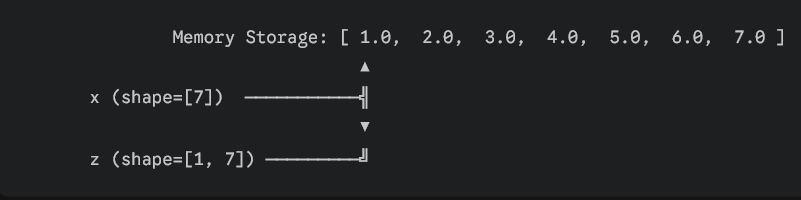    


**3. Why changing z changes x**


Because they share the same memory, when you write z[:, 0] = 5, you are telling PyTorch: "Go to the first element in the underlying memory storage and overwrite it with 5."

The memory storage instantly updates:

Memory Storage: [ 5.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0 ]
When you print z and x, they both look at that same mutated storage and reflect the change:

z outputs: tensor([[5., 2., 3., 4., 5., 6., 7.]])

x outputs: tensor([5., 2., 3., 4., 5., 6., 7.])


**How to avoid this?**
If you want to change the shape of a tensor but want to make sure it becomes a completely independent copy that won't mess with your original data, use .clone() right before or after changing the shape:

Python
# This safely breaks the connection
z = x.view(1, 7).clone()

# Or use reshape, which automatically copies data if a view isn't possible
z = x.reshape(1, 7).clone()


In [ ]:
# Changing z changes x
z[:, 0] = 5
z, x

(tensor([[5., 2., 3., 4., 5., 6., 7.]]), tensor([5., 2., 3., 4., 5., 6., 7.]))


If we wanted to stack our new tensor on top of itself five times, we could do so with torch.stack().

In [ ]:
# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=0) # try changing dim to dim=1 and see what happens
x_stacked

tensor([[5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.]])

Row 0 -> [5., 2., 3., 4., 5., 6., 7.]
Row 1 -> [5., 2., 3., 4., 5., 6., 7.]
Row 2 -> [5., 2., 3., 4., 5., 6., 7.]
Row 3 -> [5., 2., 3., 4., 5., 6., 7.]

In [ ]:
# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=1) # try changing dim to dim=1 and see what happens
x_stacked

tensor([[5., 5., 5., 5.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [7., 7., 7., 7.]])

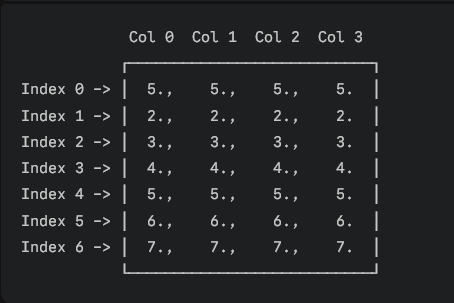

dim=0: Shape becomes [number_of_tensors, tensor_length] $\rightarrow$ [4, 7]

dim=1: Shape becomes [tensor_length, number_of_tensors] $\rightarrow$ [7, 4]

In [ ]:
print(f"Previous tensor: {x_reshaped}")
print(f"Previous shape: {x_reshaped.shape}")

# Remove extra dimension from x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
Previous shape: torch.Size([1, 7])

New tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
New shape: torch.Size([7])


In [ ]:
print(f"Previous tensor: {x_squeezed}")
print(f"Previous shape: {x_squeezed.shape}")

## Add an extra dimension with unsqueeze
x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(f"\nNew tensor: {x_unsqueezed}")
print(f"New shape: {x_unsqueezed.shape}")

Previous tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
Previous shape: torch.Size([7])

New tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
New shape: torch.Size([1, 7])


In [ ]:
# Create a tensor
import torch
x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [ ]:
# Let's index bracket by bracket
print(f"First square bracket:\n{x[0]}")
print(f"Second square bracket: {x[0][0]}")
print(f"Third square bracket: {x[0][0][0]}")

First square bracket:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Second square bracket: tensor([1, 2, 3])
Third square bracket: 1


In [ ]:
# Get all values of 0th dimension and the 0 index of 1st dimension
x[:, 0]

tensor([[1, 2, 3]])

Dimension 0 (The Block)

Dimension 1 (The Rows)

Dimension 2 (The Columns)

   [[[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]]]

x[:, :, 1] $\rightarrow$ tensor([[2, 5, 8]])

: (Dim 0): Keep all blocks.

: (Dim 1): Keep all rows.

1 (Dim 2): Extract only the values at Column index 1.

Result: It goes down Column 1 and pulls out 2, 5, and 8.

x[:, 1, 1] $\rightarrow$ tensor([5])

: (Dim 0): Keep all blocks.

1 (Dim 1): Go to Row 1.

1 (Dim 2): Go to Column 1.

Result: This functions like a crosshair targeting a single coordinate. It pinpoints the exact intersection of Row 1 and Column 1, which contains the value 5.

In [ ]:
# Get all values of 0th & 1st dimensions but only index 1 of 2nd dimension
x[:, :, 1]

tensor([[2, 5, 8]])

In [ ]:
# Get all values of the 0 dimension but only the 1 index value of the 1st and 2nd dimension
x[:, 1, 1]

tensor([5])

x[0, 0, :] $\rightarrow$ tensor([1, 2, 3])

0 (Dim 0): Look inside the first block.

0 (Dim 1): Look inside the first row.

: (Dim 2): Give me all columns across that row.

Result: Because you used specific integer coordinates (0, 0) instead of slices (:) for the first two dimensions, PyTorch drops those extra outer dimensions and leaves you with a clean, flat 1D tensor of that row: tensor([1, 2, 3]).

In [ ]:
# Get index 0 of 0th and 1st dimension and all values of 2nd dimension
x[0, 0, :] # same as x[0][0]

tensor([1, 2, 3])

x[:, 0] $\rightarrow$ tensor([[1, 2, 3]])

: (Dim 0): Keep all blocks (there is only 1 block at index 0).

0 (Dim 1): Look only at Row 0 inside that block.

**Missing Dim 2:** Because you didn't specify the 2nd dimension, PyTorch defaults to giving you all columns for that row.

**Result: **It grabs the entire first row [1, 2, 3]. Because the first dimension : was kept, it preserves its structure as a 2D matrix view: [[1, 2, 3]].

Since NumPy is a popular Python numerical computing library, PyTorch has functionality to interact with it nicely.

The two main methods you'll want to use for NumPy to PyTorch (and back again) are:

torch.from_numpy(ndarray) - NumPy array -> PyTorch tensor.


torch.Tensor.numpy() - PyTorch tensor -> NumPy array.


Let's try them out.

In [ ]:
# NumPy array to tensor
import torch
import numpy as np
array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

Note: By default, NumPy arrays are created with the datatype float64 and if you convert it to a PyTorch tensor, it'll keep the same datatype (as above).

However, many PyTorch calculations default to using float32.

So if you want to convert your NumPy array (float64) -> PyTorch tensor (float64) -> PyTorch tensor (float32),

you can use

tensor = torch.from_numpy(array).type(torch.float32).

In [ ]:
# Change the array, keep the tensor
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))


And if you want to go from PyTorch tensor to NumPy array, you can call tensor.numpy().

In [ ]:
# Tensor to NumPy array
tensor = torch.ones(7) # create a tensor of ones with dtype=float32
numpy_tensor = tensor.numpy() # will be dtype=float32 unless changed
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [ ]:
# Change the tensor, keep the array the same
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

Reproducibility (trying to take the random out of random)

In [ ]:
import torch

# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print(f"Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B

Tensor A:
tensor([[0.2666, 0.6274, 0.2696, 0.4414],
        [0.2969, 0.8317, 0.1053, 0.2695],
        [0.3588, 0.1994, 0.5472, 0.0062]])

Tensor B:
tensor([[0.9516, 0.0753, 0.8860, 0.5832],
        [0.3376, 0.8090, 0.5779, 0.9040],
        [0.5547, 0.3423, 0.6343, 0.3644]])

Does Tensor A equal Tensor B? (anywhere)


tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

In [ ]:
import torch
import random

# # Set the random seed
RANDOM_SEED=42 # try changing this to different values and see what happens to the numbers below
torch.manual_seed(seed=RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

# Have to reset the seed every time a new rand() is called
# Without this, tensor_D would be different to tensor_C
torch.random.manual_seed(seed=RANDOM_SEED) # try commenting this line out and seeing what happens
random_tensor_D = torch.rand(3, 4)

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print(f"Does Tensor C equal Tensor D? (anywhere)")
random_tensor_C == random_tensor_D

Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Does Tensor C equal Tensor D? (anywhere)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

In machine learning, reproducibility is the ability to obtain identical model architectures, training dynamics, and evaluation results across different runs using the same code, data, and environment. It ensures that an experiment isn't a fluke, making models reliable, auditable, and production-ready."

The Deep Dive (When they say, "Can you expand on that?")

To achieve true reproducibility, you must eliminate randomness across three distinct layers:

**Pseudo-Random Number Generators **

(PRNGs)Computers don't generate truly random numbers; they use mathematical algorithms that start from a base number called a seed. If you don't explicitly lock this seed, frameworks like PyTorch or NumPy use a random system clock time as the seed, making every run completely different.

2.**Software & Hardware Environments**

A model trained on an older version of PyTorch might behave differently on a newer version due to under-the-hood algorithmic optimizations. Similarly, hardware differences (e.g., training on an AMD CPU vs. an NVIDIA T4 GPU) can introduce subtle floating-point variations.

3.**Non-Deterministic Operations**

Certain deep learning operations—especially atomic operations used in GPU acceleration (like CUDA convolution algorithms)—prioritize execution speed over mathematical order. Because floating-point addition is non-associative ($A + B + C \neq C + B + A$ at extreme decimals), changing the order of execution changes the final weights.

In [ ]:
import torch
import numpy as np
import random

# 1. Set seeds for all standard libraries
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# 2. Set seed specifically for GPU operations
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED) # For multi-GPU

# 3. Force CUDA to use deterministic algorithms (Sacrifices a bit of speed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

you can test if PyTorch has access to a GPU using torch.cuda.is_available().


If the above output "cuda" it means we can set all of our PyTorch code to use the available CUDA device (a GPU) and if it output "cpu", our PyTorch code will stick with the CPU.



In [ ]:
# Set device type
device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
# Count number of devices
torch.cuda.device_count()

In [ ]:
# If tensor is on GPU, can't transform it to NumPy (this will error)
tensor_on_gpu.numpy()

NameError: name 'tensor_on_gpu' is not defined

**The Problem:**

Two Different Memory Pools
NumPy arrays are strictly bound to your system RAM (CPU memory). They cannot live on or interact directly with your VRAM (GPU memory).

When you move a PyTorch tensor to the GPU (e.g., using .to("cuda")), it leaves your system RAM and enters the GPU's memory pool so that the graphics card can accelerate its math. If you try to call .numpy() directly on a GPU tensor, PyTorch blocks it because NumPy has no way of reading data that lives inside the GPU.

**The Solution: **

Bring it Back to the CPU First
To convert a GPU tensor into a NumPy array, you must explicitly pass it back to the CPU memory pool using the .cpu() method before calling .numpy().



In [ ]:
import torch

# 1. Create a tensor and move it to the GPU
tensor_on_gpu = torch.tensor([1.0, 2.0, 3.0]).to("cuda")

# 2. Convert to NumPy safely by moving it to CPU first
numpy_array = tensor_on_gpu.cpu().numpy()

print(numpy_array)
# Output: array([1., 2., 3.], dtype=float32)

[1. 2. 3.]


NumPy was created in the mid-2000s, long before GPUs were widely used for general-purpose computing or deep learning.

Under the hood, a NumPy array is just a wrapper around a raw pointer to a sequential block of memory in System RAM. When NumPy executes a function (like adding two arrays), it calls compiled C or Fortran code that tells the CPU to go to those specific RAM addresses and do the math.

The CPU physically does not have the instructions or the direct electrical routing to manipulate pointers pointing inside the GPU's VRAM. If you handed a VRAM memory address to NumPy, the CPU would try to look it up in standard RAM, find nothing (or the wrong data), and crash.